In [28]:
# Import the  necessary packages for SVM and metrics
import pandas as pd
from sklearn import svm
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

#read the dataset
df = pd.read_csv('Diabetes_prediction.csv')

Linear SVC accuracy: 69.40%
Sigmoid SVC accuracy: 59.70%
RBF SVC accuracy: 80.90%
Poly SVC accuracy: 69.40%


C:\Users\rathn\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\rathn\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\rathn\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\rathn\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


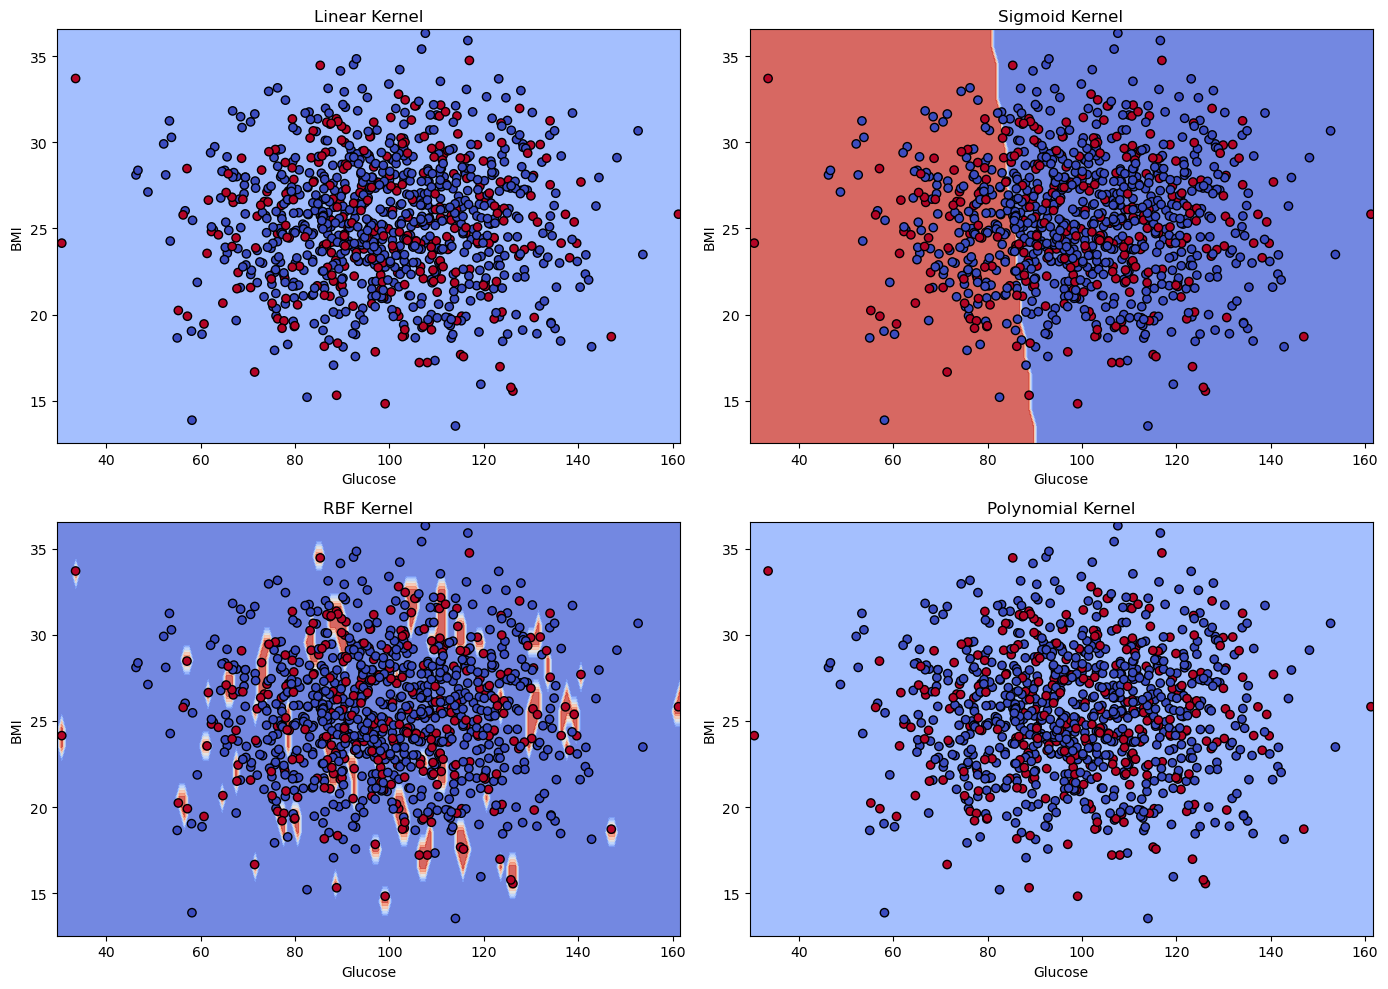

In [32]:
# Select features and target
X = df[['Glucose', 'BMI']]
Y = df['Diagnosis']
# Define four SVM models with different kernels
svc_linear = svm.SVC(kernel='linear', C=1).fit(X, Y)
svc_sigmoid = svm.SVC(kernel='sigmoid', C=1).fit(X, Y)
svc_rbf = svm.SVC(kernel='rbf', gamma=0.7, C=1).fit(X, Y)
svc_poly = svm.SVC(kernel='poly', degree=3, C=1).fit(X, Y)

# Predictions and accuracy for  models
models = {'Linear SVC': svc_linear, 'Sigmoid SVC': svc_sigmoid, 'RBF SVC': svc_rbf, 'Poly SVC': svc_poly}
for name, model in models.items():
    predictions = model.predict(X)
    accuracy = accuracy_score(Y, predictions) * 100
    print(f'{name} accuracy: {accuracy:.2f}%')
# Plotting decision boundaries
h = 1
x_min, x_max = X['Glucose'].min() - 1, X['Glucose'].max() + 1
y_min, y_max = X['BMI'].min() - 1, X['BMI'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Titles for the plots
titles = ['Linear Kernel', 'Sigmoid Kernel', 'RBF Kernel', 'Polynomial Kernel']

plt.figure(figsize=(14, 10))
for i, (name, model) in enumerate(models.items()):
    plt.subplot(2, 2, i + 1)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X['Glucose'], X['BMI'], c=Y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.xlabel('Glucose')
    plt.ylabel('BMI')
    plt.title(titles[i])
#plot
plt.tight_layout()
plt.show()